In [1]:
pip install -U pytorch-lightning segmentation-models-pytorch

/Users/fidok/Developer/Solvro/ml-kurs-wdrozeniowy-25/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
from torchvision import transforms
import pytorch_lightning as pl
from torchvision.datasets import OxfordIIITPet

## Dane
Wykorzystamy zbiór [OxfordIIITPet](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html#oxfordiiitpet) do obu zadań, natomiast sposób ich wczytania będzie inny dla zadania segmentacji (wymaga zmiany **target_types** na "segmentation"). Do drugiej części wczytujemy obrazki jak do zadania klasyfikacji.
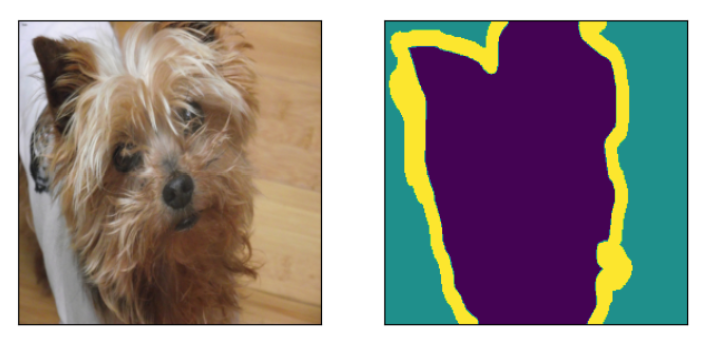



## Zadanie 0

Wczytaj zbiór OxfordIIIPet do zadania segmentacji, zbadaj co zawiera w środku oraz wyświetl przykładową maskę.

In [3]:
# wczytaj zbiór z torchvision
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

target_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),  # Dla masek NEAREST!
    transforms.PILToTensor(),
    transforms.Lambda(lambda x: (x - 1).squeeze().long())
])

train_dataset_to_split = torchvision.datasets.OxfordIIITPet(root='./data', 
                                                        split='trainval',
                                                        target_types='segmentation',
                                                        download=True, 
                                                        transform=transform,
                                                        target_transform=target_transform)

test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', target_types='segmentation',
                                               download=True, transform=transform, target_transform=target_transform)

dataset_size = len(train_dataset_to_split)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(train_dataset_to_split, [train_size, val_size])

# załaduj do DataLoadera (pamiętaj o podziale train, val, test)


train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

## U-Net

Jest to popularna architektura która ma swój początek w zadaniu **segmentacji** biomedycznej. Do tej pory mieliśmy styczność z klasyfikacją, gdzie każdemu obrazkowi przypisywaliśmy kategorię, natomiast segmentacja polega na przypisaniu każdemu pikselowi kategorii.

Architektura składa się z enkodera i dekodera, pośredniej warstwy bottlenecka i połączeń typu skip (aka' pomost). Sieć enkodera jest klasyczną siecią konwolucyjną, w której zwiększa się liczba kanałów kosztem zmniejszenia rozdzielczości mapy. Sieć dekodera składa się z warstw *dekonwolucji*, które mają w przeciwieństwie do zwykłej konwolucji zwiększać rozdzielczość obrazka i zmniejszać liczbę kanałów. Dzięki temu końcowy wynik ma taki sam rozmiar jak wejściowy obrazek, co reprezentuje przypisanie klasy per piksel. Połączenia pomostowe służą do konkatenacji map z enkodera i dekodera, a celem jest zachowanie informacji na temat tego "co" i "gdzie" się znajduje. Dobre wytłumaczenie znajduje się [tutaj](https://www.kaggle.com/code/akshitsharma1/unet-architecture-explained-in-one-shot-tutorial).

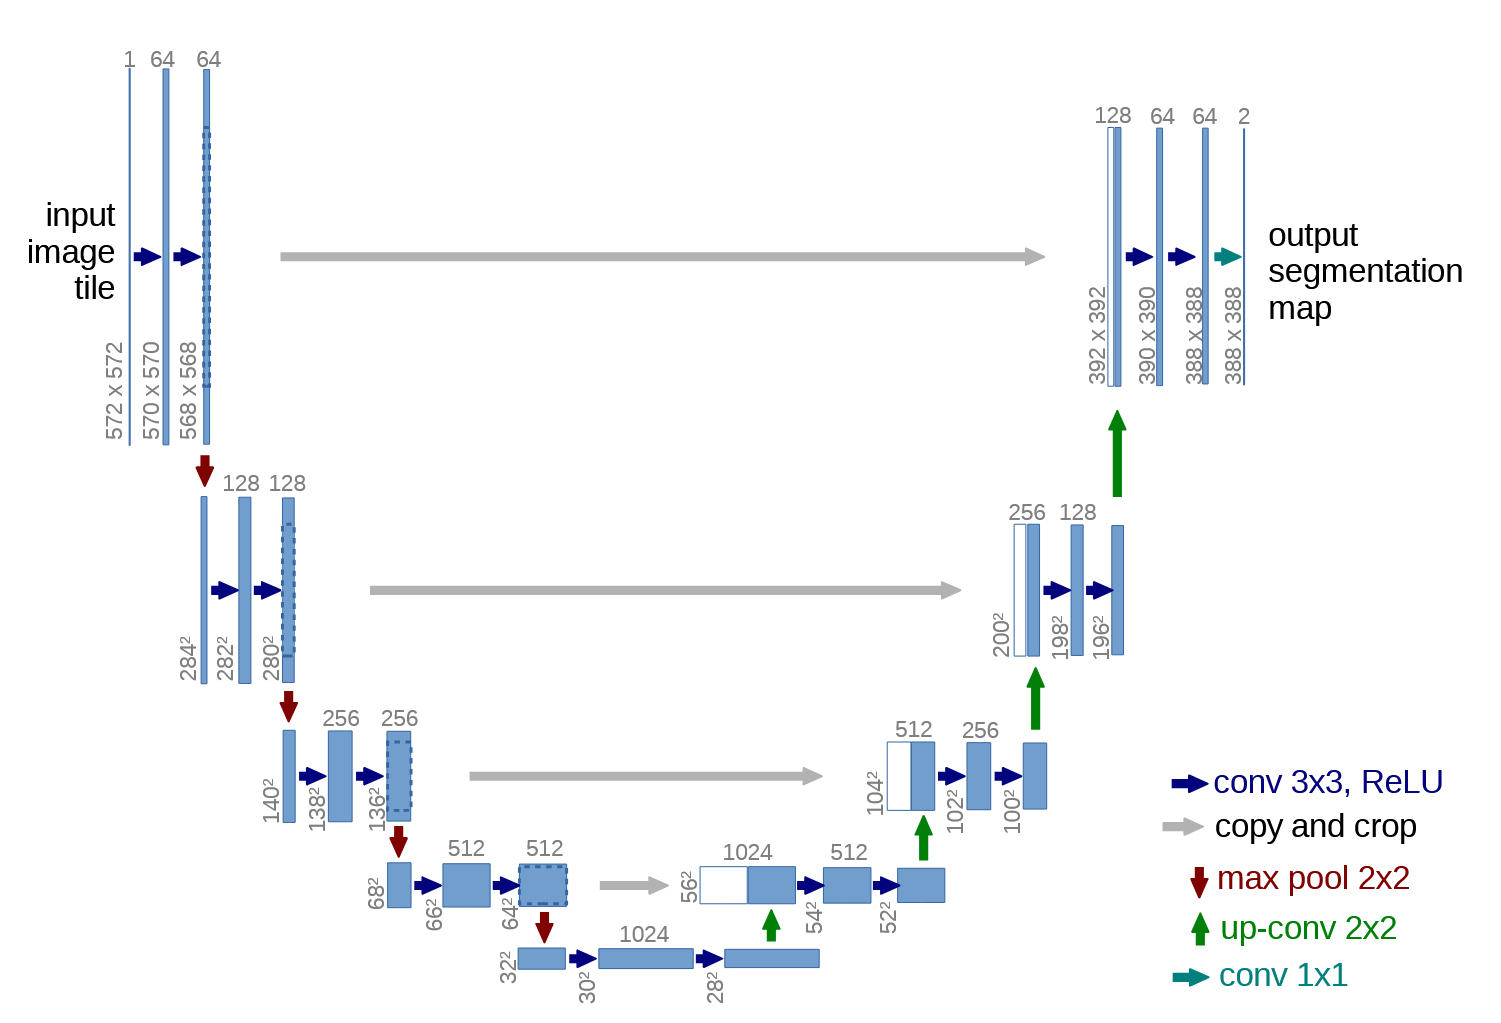

## Dekonwolucja

Dekonwolucja jest bratnią operacją konwolucji, ale jak już było wspomnianie, jej celem jest zwiększenie wymiarów przestrzennych. Składa się ona z kroków
- Upsampling: zwiększenie rozmiaru mapy zwykle dodając "puste" wiersze i kolumny
- Convolution: warstwa konwolucyjna (logiczne - czegoś też chcemy się nauczyć)
- Stride: $> 1$ zwiększa wymiar przestrzenny mapy
- Padding: to samo co w zwykłej konwolucji
- Activation: funkcja aktywacji (nieliniowa!, zwykle ReLU)

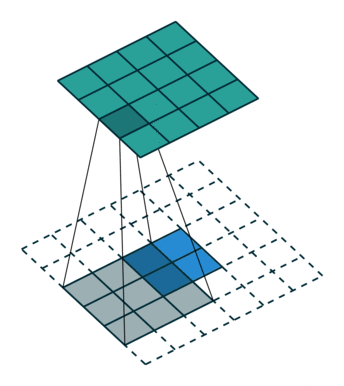

## Zadanie 1.1
Zaimplementuj blok warstwy enkodera, który będzie wykonywał m.in. operację konwolucji (zmniejszanie wymiary przestrzennego) oraz max-pooling. Jedną pułapką jest tutaj fakt, że enkoder musi zwracać dwie rzeczy - $x_{skip}$ jako wejście do dekodera, oraz $x_{down}$ po warstwie poolingu do dalszej warstwy enkodera.

$x_{skip} = ConvBlock(x)$

$x_{down} = MaxPool(x_{skip})$

gdzie $ConvBlock$ stanowi pipeline *konwolucja, batch-normalization, aktywacja* powtórzone $M$ razy (może być raz). Jest on już zaimplementowany niżej jako ```DoubleConv``` - możesz go dostosować do swoich potrzeb lub zostawić jak jest.

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None):
        super().__init__()

        if not hidden_channels:
            hidden_channels = out_channels

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [5]:
class DownBlock(nn.Module): # blok budulcowy enkodera

  def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None): # dodaj parametry
    super().__init__()

    self.conv = DoubleConv(in_channels, out_channels)
    self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    pass

  def forward(self, x): # dodaj parametry    
    x_skip = self.conv(x)
    x_down = self.max_pool(x_skip)
    
    return x_skip, x_down

## Zadanie 1.2
Zaimplementuj *blok* warstwy dekodera, która będzie wykonywała operację dekonwolucji oraz konkatenacji cech z enkodera. Przetwarzanie powinno być według schematu:

*$x_{up} = ConvTranspose(x)$

$x_{cat} = Concat(x_{up}, s)$

$y = ConvBlock(x_{out})$

Nowa warstwa dekonwolucji jest zaimplementowana w torchu [ConvTranspose2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html). Należy zwrócić uwagę na **zgodność kształtów** oraz **liczbę kanałów** (szczególnie po konkatenacji!).

*alternatywnie można użyć warswty [Upsamplingu](https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html) + konwolucji

In [6]:
class UpBlock(nn.Module): # blok budulcowy dekodera

  def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None): # dodaj parametry
    super().__init__()

    self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
    self.conv = DoubleConv(in_channels, out_channels)
    
    pass

  def forward(self, x, skip): # dodaj parametry
    x_up = self.up(x)
    x_cat = torch.cat([x_up, skip], dim=1)
    
    return self.conv(x_cat)

Zalecam zrobienie krótkiego sanity-check aby sprawdzić, czy dwa bloki łączą się poprawnie

In [7]:
x = torch.randn(1, 3, 128, 128)
down_block = DownBlock(in_channels=3, out_channels=64) # dodaj argumenty
up_block = UpBlock(in_channels=128, out_channels=64) # dodaj argumenty

x_skip, x_down = down_block(x)

x_bottleneck = torch.randn(1, 128, 64, 64)

x_up = up_block(x_bottleneck, x_skip)

print(x_skip.shape, x_down.shape, x_up.shape)

torch.Size([1, 64, 128, 128]) torch.Size([1, 64, 64, 64]) torch.Size([1, 64, 128, 128])


## Zadanie 2.1
Następnym zadaniem jest wykorzystanie bloków do implementacji pełnej sieci. Niech nasza sieć składa się z N bloków enkodera $(E1​...En​)$, jednego bottlenecku $(B)$ i N bloków dekodera $(Dn​...D1​)$. Schemat będzie miał postać:

#### Enkoder
1. $(x1​,s1​)=E1​(input)$
2. $(x2​,s2​)=E2​(x1​)$
3. $(x3​,s3​)=E3​(x2​)$
4. $(x4​,s4​)=E4​(x3​)$

#### Bottleneck
5. $b=B(x4​)$ (zwykły blok konwolucyjny)

#### Dekoder
6. $d4​=D4​(b,s4​)$
7. $d3​=D3​(d4​,s3​)$
8. $d2​=D2​(d3​,s2​)$
9. $d1​=D1​(d2​,s1​)$

#### Spłaszczenie wyjścia
10. $output=Conv_{1x1}(d1​)$ --> wykorzystuje konwolucję $1x1$ do pozbycia się wymiaru kanału. Otrzymujemy tutaj $H \times W \times K$ predykcji (bo dla każdego piksela) i każdej klasy.

Wskazówki
- Rozmiar wejściowy: Musi być podzielny przez $2^{liczba poziomów}$ (dlaczego?), najlepiej używać potęg dwójki typu 256, 512
- Padding: równy 1
- Liczba kanałów: w enkoderze podwajamy $64 → 128 → 256$, w dekoderze dzielimy przez dwa $256 → 128 → 64$
- Konkatenacja: po wymiarze kanałów
- Wyjście: musi być takiego samo wymiary przestrzennego jak wejście, a liczba kanałów będzie odpowiadać liczbie klas.

In [8]:
class UNet(nn.Module):

  def __init__(self, n_channels, n_classes):
    super().__init__()
    # tutaj bloki budulcowe
    self.inc = DoubleConv(n_channels, 64)
    self.down1 = DownBlock(64, 128)
    self.down2 = DownBlock(128, 256)
    self.down3 = DownBlock(256, 512)
    self.down4 = DownBlock(512, 1024)

    self.up1 = UpBlock(1024, 512)
    self.up2 = UpBlock(512, 256)
    self.up3 = UpBlock(256, 128)

    self.outc = nn.Conv2d(128, n_classes, kernel_size=1)
    pass

  def forward(self, x):
    x1 = self.inc(x)
    s1, p1 = self.down1(x1)
    s2, p2 = self.down2(p1)
    s3, p3 = self.down3(p2)
    s4, p4 = self.down4(p3)

    x = self.up1(s4, s3)
    x = self.up2(x, s2)
    x = self.up3(x, s1)

    clas = self.outc(x)
    
    return clas

## Zadanie 2.2
Kolejnym krokiem jest wyuczenie sieci do zadania segmentacji. Wykorzystaj ```nn.CrossEntropyLoss``` jako funkcję straty (lub posłuż się bardziej dostosowanymi metrykami jak [Dice Loss](https://smp.readthedocs.io/en/latest/losses.html#diceloss) jeśli uczenie będzie szło bardzo źle). W tym celu konieczne będzie spłaszczenie wyniku $B \times W \times H \times K$ do $B \times (WH) \times K$. Wyświetl krzywą uczenia oraz dokładność dla każdej klasy. Dodatkowo zbieraj co $M$ epok przykładowe predykcje (dla zbioru walidacyjnego) i wyświetl jak w trakcie trenowania zmieniała się maska segmentacji (najlepiej zostaw dataloder dla zbioru val z ```shuffle=False```)

In [9]:
from tqdm import tqdm
# trenowanie, wyświetlanie wyników
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

model = UNet(n_channels=3, n_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


num_epochs = 5

p_results = 1

history = {
    'train_loss': [], 'val_loss': [],
    'class_acc': {0: [], 1: [], 2: []}
}
visualization_samples = []

fixed_x, fixed_y = next(iter(val_loader))
fixed_x = fixed_x[0:1].to(device)
fixed_y = fixed_y[0:1].to(device)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    #nowe fajne pasek postepu 
    loop = tqdm(train_loader)

    for images, masks in loop:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0 

    correct = {0: 0, 1: 0, 2: 0}
    all = {0: 0, 1: 0, 2: 0}
    
    with torch.no_grad():
        val_loop = tqdm(val_loader)

        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            for cls in [0, 1, 2]:
                mask_for_class = (masks == cls)
                
                if mask_for_class.sum() > 0:
                    
                    all[cls] += mask_for_class.sum().item()
                    
                    hits = (preds == masks) & mask_for_class
                    correct[cls] += hits.sum().item()

        if (epoch + 1) % p_results == 0 or epoch == 0:
            sample_out = model(fixed_x)
            sample_pred = torch.argmax(sample_out, dim=1)
            visualization_samples.append((epoch+1, sample_pred.cpu().squeeze(), fixed_y.cpu().squeeze()))

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    for cls in [0, 1, 2]:
        acc = correct[cls] / (all[cls] + 1e-6)
        history['class_acc'][cls].append(acc)

100%|██████████| 184/184 [01:46<00:00,  1.73it/s]


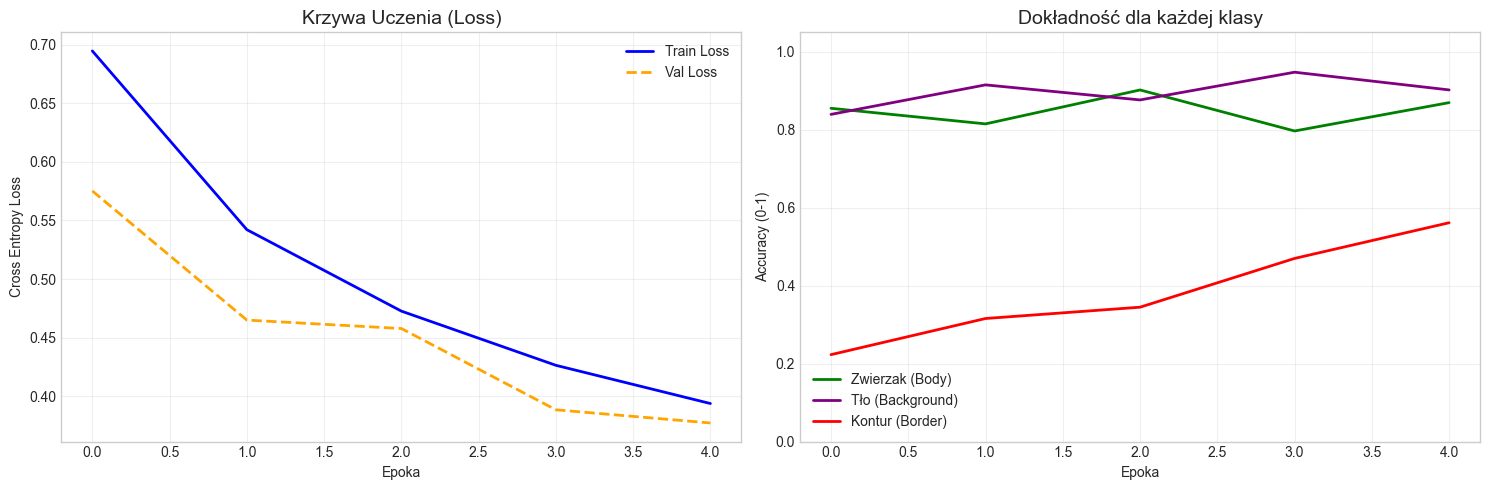

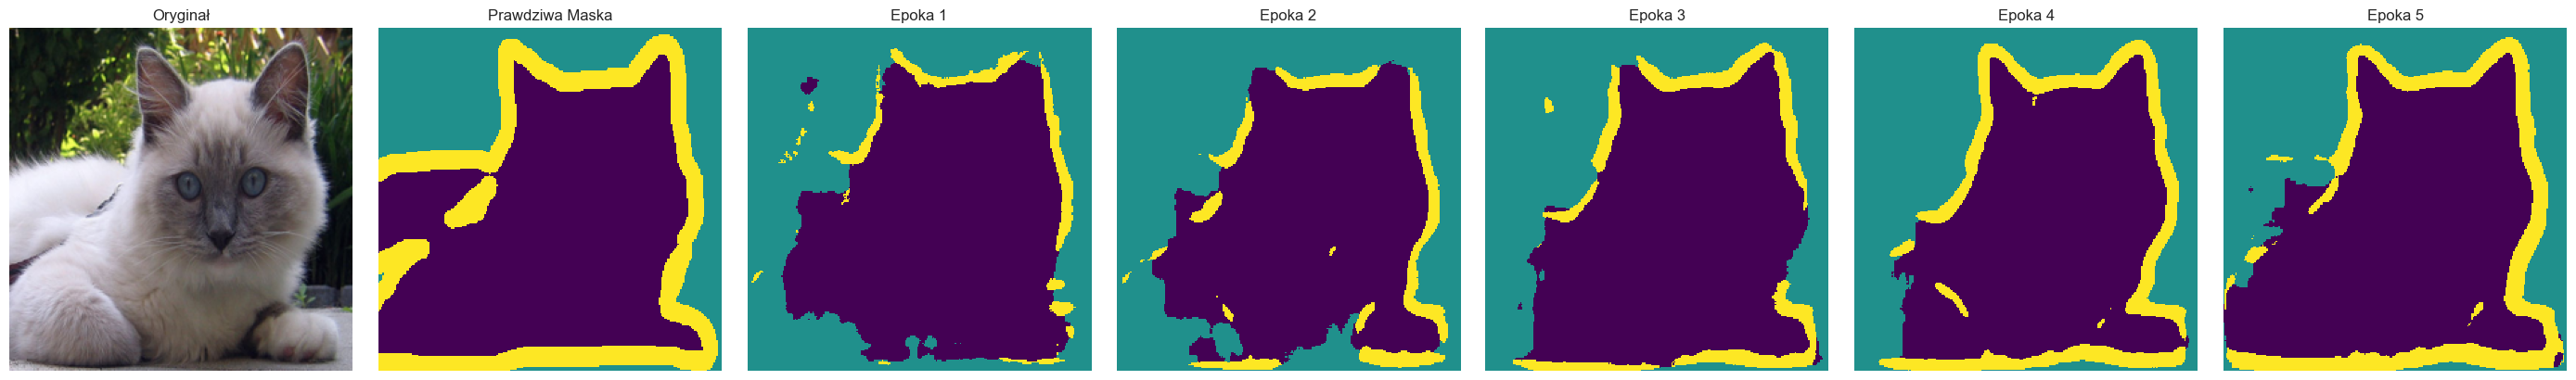

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Ustawiamy styl wykresów na bardziej czytelny
plt.style.use('seaborn-v0_8-whitegrid')

# Tworzymy duży rysunek z dwoma wykresami obok siebie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- 1. WYKRES LOSS ---
ax1.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title("Krzywa Uczenia (Loss)", fontsize=14)
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- 2. WYKRES DOKŁADNOŚCI (ACCURACY) ---
colors = {0: 'green', 1: 'purple', 2: 'red'}
labels = {0: 'Zwierzak (Body)', 1: 'Tło (Background)', 2: 'Kontur (Border)'}

for cls in [0, 1, 2]:
    ax2.plot(history['class_acc'][cls], label=labels[cls], color=colors[cls], linewidth=2)

ax2.set_title("Dokładność dla każdej klasy", fontsize=14)
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Accuracy (0-1)")
ax2.set_ylim(0, 1.05) # Skala od 0 do 100%
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. WIZUALIZACJA POSTĘPÓW SEGMENTACJI ---
# Chcemy zobaczyć: Obrazek Oryginalny | Prawdziwą Maskę | Predykcje z kolejnych etapów

# Ile mamy zapisanych "klatek"?
num_snaps = len(visualization_samples)
cols = num_snaps + 2 # +2 bo dodajemy oryginał i maskę ground truth

fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4))

# A. Oryginalny obrazek (RGB)
# Musimy go "odnormalizować", żeby wyglądał naturalnie
# Mean i Std z ImageNet (użyte w transform)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_display = fixed_x.cpu().squeeze().permute(1, 2, 0).numpy()
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1) # Przycinamy wartości do zakresu [0,1]

axes[0].imshow(img_display)
axes[0].set_title("Oryginał", fontsize=12)
axes[0].axis('off')

# B. Prawdziwa Maska (Ground Truth)
axes[1].imshow(fixed_y.cpu().squeeze(), cmap='viridis', interpolation='nearest')
axes[1].set_title("Prawdziwa Maska", fontsize=12)
axes[1].axis('off')

# C. Predykcje z treningu
for i, (epoch_num, pred, target) in enumerate(visualization_samples):
    ax = axes[i + 2]
    ax.imshow(pred, cmap='viridis', interpolation='nearest')
    ax.set_title(f"Epoka {epoch_num}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Autoenkoder

Autoenkoder to architektura zaliczana do uczenia nienadzorowanego (unsupervised learning), co oznacza, że trenujemy ją wyłącznie na danych wejściowych, bez udziału etykiet. Model ten składa się z połączonego enkodera i dekodera, a jego celem jest minimalizacja błędu rekonstrukcji wejścia (np. Mean Squared Error).

Matematycznie problem ten sprowadza się do znalezienia takiego zbioru parametrów θ, który minimalizuje funkcję straty: $$ L(x^{(t)}, g_{\theta}(f_{\theta}(x^{(t)}))) $$ dla *enkodera* $f$ i *dekodera* $g$. Kluczową cechą jest to, że wymiar na wyjściu enkodera jest zazwyczaj mniejszy niż danych wejściowych. Ma to na celu wymuszenie kompresji danych do tzw. przestrzeni ukrytej (latent space), co zapobiega nauczeniu się przez sieć trywialnej funkcji tożsamościowej. Dekoder zajmuje się następnie rekonstrukcją oryginalnego obrazu na podstawie tej skompresowanej reprezentacji.

Bardzo dobrą praktyką jest celowe zaszumianie danych wejściowych na etapie treningu. Działa to jak silna regularyzacja – enkoder musi wtedy nauczyć się ekstrahować najważniejsze, kluczowe cechy danych, aby być w stanie odtworzyć czysty sygnał. Tak wytrenowany autoenkoder znajduje zastosowanie głównie w tworzeniu zwartych osadzeń danych (embeddingów), które mogą zostać wykorzystane w dalszych etapach, np. w zadaniu klasyfikacji.

### Przepływ danych

1. Enkoder: zajmuje się kompresją wejściowego obrazu, zwykle do zmniejszania rozmiaru przestrzennego używamy $stride=2$ zamiast max-pooling.
2. Bottleneck: punkt największej kompresji, wykorzystuje znany już $AdaptiveAvgPool2d$ aby wymusić mały rozmiar przestrzenny (np. $2 \times 2$) do dekodowania
3. Dekoder: odbudowuje obraz z wykorzystaniem wcześniej omawianych transponowanych konwolucji.

### Funkcja straty
Wykorzystamy funkcję straty [MSE](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#mseloss) do porównania obrazu wejściowego i zrekonstruowanego. Alternatywnie może być wykorzystane [MAE](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) ponieważ jest mniej odporne na wartości odstające. Wartości obrazu powinny być znormalizowane, ale wyjścia sieci nie muszą być ograniczone.

## Zadanie 3.1

Zaimplementuj sieć autoenkoder. Będzie ona podobna do sieci U-Net, natomiast nie używa *skip connections* do połączenia dwóch części (ma prostszy schemat). Wyucz sieć traktując obraz wejściowy jako "labele" (pamiętamy, że jest to zadanie nienadzorowane, ale nadal potrzebujemy jakiegoś ground-truth). Wyświetl ciekawsze przykłady rekonstrukcji i zawrzyj wnioski na temat łatwości uczenia sieci i jakości zrekonstruowanych obrazów.

**Uwaga**: możecie wczytać zbiór danych do nauki na wszytkich $37$ klasach, lub tylko na klasach binarnych - dla **target_types=binary-category**. Nie ma to oczywiście znaczenia do nauki autoenkodera, ale w zadaniu 3.2 potrzebne są kategorie - być może lepiej będzie zwizualizować tylko jak przestrzeń się układa dla psów i kotów, niż dla każdej z 37 klas.

In [10]:
class Encoder(nn.Module): # oddzielne sieci dla przejrzystości i łatwości dalszego użycia

  def __init__(self):
    pass

  def forward(self):
    pass

In [11]:
class Decoder(nn.Module):

  def __init__(self):
    pass

  def forward(self):
    pass

In [12]:
class CNNAutoencoder(nn.Module): # łączymy tutaj logikę enkodera i dekodera
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def embeddings(self, x): # użyj tylko enkodera i zwróc spłaszczony wynik
      pass


### Zadanie 3.2
Wyucz sieć autoeknkodera. Klasycznie loguj funkcję straty (czy będziesz logować accuracy??), oraz zbieraj rekonstrukcje dla zbioru walidacyjnego w trakcie uczenia i wyświetl jak się zmieniały w trakcie trenowania. Eksperymenty wykonaj dla różnej wielkości *bottlenecka* (np. $4, 16, 32$) i zapisz swoje obserwacje.

## *Zadanie 3.3
Zwizualizuj wektor osadzeń przy pomocy *T-SNE*. Do tego celu potrzeba będzie spłaszczyć mapę powstałą w wyniku przejścia przez enkoder. Nie jest tutaj potrzebna sieć dekodera. Zwróć uwagę na to, czy klasy są wizualnie dobrze rozdzielone.